# RnD-1: множественные проверки, баланс групп и повторное случайное разбиение

Этот ноутбук демонстрирует три основные идеи, связанные с первым RnD:

1. как растёт вероятность ложного сигнала при большом числе проверяемых признаков;
2. как ведут себя разные способы учёта множественности;
3. почему для контроля баланса групп часто удобнее ориентироваться на величину дисбаланса, а не на набор p-value.

Дополнительно показан многомерный критерий Хотеллинга $T^2$ для блока количественных признаков.


## План экспериментов

- **Эксперимент 1.** Вероятность хотя бы одного ложного сигнала при росте числа признаков $K$.
- **Эксперимент 2.** Сравнение подходов: без поправки, Бонферрони, Холм, Бенджамини—Хохберг.
- **Эксперимент 3.** Сравнение двух правил для повторного случайного разбиения:
  - отклонять разбиение, если хотя бы по одному признаку есть малое p-value;
  - отклонять разбиение, если максимальное стандартизированное различие превышает порог.
- **Эксперимент 4.** Иллюстрация критерия Хотеллинга $T^2$ как общего теста по нескольким количественным признакам.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import f

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)


## Вспомогательные функции

In [3]:
def welch_pvalues(X, g):
    """Возвращает p-value для каждой колонки X при сравнении групп g in {0,1}."""
    x0 = X[g == 0]
    x1 = X[g == 1]
    return stats.ttest_ind(x0, x1, axis=0, equal_var=False).pvalue

def bonferroni_any_reject(pvals, alpha=0.05):
    m = len(pvals)
    return np.min(pvals) < alpha / m

def holm_any_reject(pvals, alpha=0.05):
    p = np.sort(np.asarray(pvals))
    m = len(p)
    for i, pv in enumerate(p, start=1):
        if pv <= alpha / (m - i + 1):
            return True
    return False

def bh_any_reject(pvals, alpha=0.05):
    p = np.sort(np.asarray(pvals))
    m = len(p)
    thresholds = alpha * np.arange(1, m + 1) / m
    return np.any(p <= thresholds)

def smd_vector(X, g):
    x0 = X[g == 0]
    x1 = X[g == 1]
    m0, m1 = x0.mean(axis=0), x1.mean(axis=0)
    v0, v1 = x0.var(axis=0, ddof=1), x1.var(axis=0, ddof=1)
    pooled = np.sqrt((v0 + v1) / 2.0)
    pooled = np.where(pooled == 0, 1e-12, pooled)
    return (m1 - m0) / pooled

def max_abs_smd(X, g):
    return np.max(np.abs(smd_vector(X, g)))

def hotellings_t2_two_sample(X, g):
    x0 = X[g == 0]
    x1 = X[g == 1]
    n0, n1 = len(x0), len(x1)
    p = X.shape[1]
    if min(n0, n1) <= 1 or (n0 + n1 - p - 1) <= 0:
        return np.nan, np.nan, np.nan
    mean_diff = x1.mean(axis=0) - x0.mean(axis=0)
    S0 = np.cov(x0, rowvar=False, ddof=1)
    S1 = np.cov(x1, rowvar=False, ddof=1)
    Sp = ((n0 - 1) * S0 + (n1 - 1) * S1) / (n0 + n1 - 2)
    Sp_inv = np.linalg.pinv(Sp)
    T2 = (n0 * n1) / (n0 + n1) * mean_diff @ Sp_inv @ mean_diff
    F_stat = ((n0 + n1 - p - 1) / (p * (n0 + n1 - 2))) * T2
    pvalue = 1 - f.cdf(F_stat, p, n0 + n1 - p - 1)
    return T2, F_stat, pvalue

def simulate_null_dataset(n=400, k=20, rho=0.3, seed=None):
    local_rng = np.random.default_rng(seed)
    cov = np.full((k, k), rho)
    np.fill_diagonal(cov, 1.0)
    X = local_rng.multivariate_normal(mean=np.zeros(k), cov=cov, size=n)
    g = local_rng.integers(0, 2, size=n)
    return X, g

def rerandomize_by_pvalue(X, alpha=0.05, max_iter=5000, seed=0):
    local_rng = np.random.default_rng(seed)
    n = len(X)
    for i in range(1, max_iter + 1):
        g = local_rng.integers(0, 2, size=n)
        pvals = welch_pvalues(X, g)
        if np.min(pvals) >= alpha:
            return i, g, pvals
    return None, None, None

def rerandomize_by_smd(X, tau=0.1, max_iter=5000, seed=0):
    local_rng = np.random.default_rng(seed)
    n = len(X)
    for i in range(1, max_iter + 1):
        g = local_rng.integers(0, 2, size=n)
        score = max_abs_smd(X, g)
        if score <= tau:
            return i, g, score
    return None, None, None


## Эксперимент 1. Рост вероятности ложного сигнала при увеличении числа признаков

In [4]:
def estimate_false_flag_rate(k_values, n=400, alpha=0.05, runs=1000, rho=0.3):
    rows = []
    for k in k_values:
        flagged = 0
        for r in range(runs):
            X, g = simulate_null_dataset(n=n, k=k, rho=rho, seed=10_000 + r + k)
            pvals = welch_pvalues(X, g)
            flagged += (np.min(pvals) < alpha)
        rows.append({"K": k, "rate_any_p_below_alpha": flagged / runs})
    return pd.DataFrame(rows)

k_values = [5, 10, 20, 50, 100]
false_flag_df = estimate_false_flag_rate(k_values=k_values, runs=800)
false_flag_df


,K,rate_any_p_below_alpha
0,5,0.21625
1,10,0.37125
2,20,0.55375
3,50,0.79125
4,100,0.95375


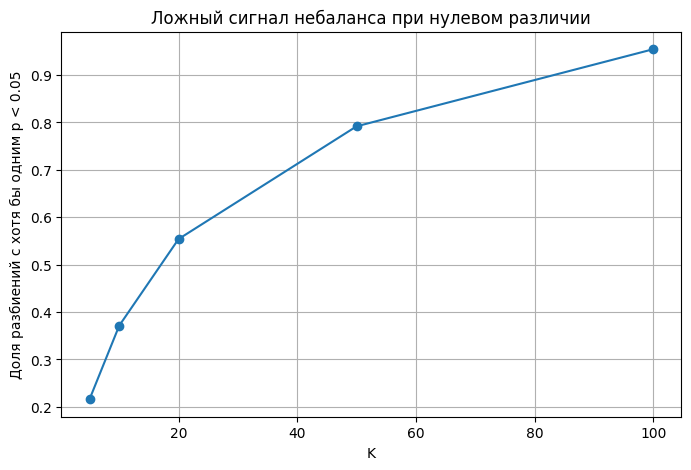

In [5]:
ax = false_flag_df.plot(x="K", y="rate_any_p_below_alpha", marker="o", legend=False)
ax.set_ylabel("Доля разбиений с хотя бы одним p < 0.05")
ax.set_title("Ложный сигнал небаланса при нулевом различии")
plt.show()


Интерпретация: даже при корректной рандомизации вероятность увидеть хотя бы один «значимый» признак быстро растёт с числом проверяемых переменных. Именно поэтому правило вида «нашлось хотя бы одно малое p-value — повторить разбиение» плохо масштабируется.

## Эксперимент 2. Сравнение способов учёта множественности

In [6]:
def compare_multiplicity_controls(k=30, n=400, alpha=0.05, runs=1500, rho=0.3):
    out = {"none": 0, "bonferroni": 0, "holm": 0, "bh_fdr": 0}
    for r in range(runs):
        X, g = simulate_null_dataset(n=n, k=k, rho=rho, seed=20_000 + r)
        pvals = welch_pvalues(X, g)
        out["none"] += (np.min(pvals) < alpha)
        out["bonferroni"] += bonferroni_any_reject(pvals, alpha)
        out["holm"] += holm_any_reject(pvals, alpha)
        out["bh_fdr"] += bh_any_reject(pvals, alpha)
    return pd.DataFrame({"method": list(out.keys()), "false_reject_rate": [v / runs for v in out.values()]})

mult_df = compare_multiplicity_controls(k=30, runs=1200)
mult_df


,method,false_reject_rate
0,none,0.642500
1,bonferroni,0.039167
2,holm,0.039167
3,bh_fdr,0.041667


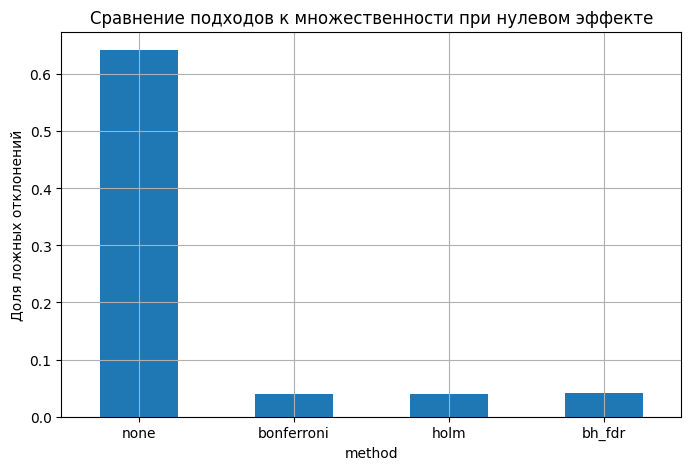

In [7]:
ax = mult_df.plot(kind="bar", x="method", y="false_reject_rate", legend=False, rot=0)
ax.set_ylabel("Доля ложных отклонений")
ax.set_title("Сравнение подходов к множественности при нулевом эффекте")
plt.show()


Интерпретация: поправки действительно уменьшают частоту ложных срабатываний. Однако это отвечает на вопрос о контроле ошибки при множественных проверках, а не делает p-value хорошей мерой фактического дисбаланса групп.

## Эксперимент 3. Два правила для повторного случайного разбиения

In [8]:
def compare_rerandomization_rules(runs=300, n=400, k=20, rho=0.3, alpha=0.05, tau=0.1):
    rows = []
    for r in range(runs):
        X, _ = simulate_null_dataset(n=n, k=k, rho=rho, seed=30_000 + r)
        it_p, g_p, pvals = rerandomize_by_pvalue(X, alpha=alpha, seed=40_000 + r)
        it_s, g_s, score_s = rerandomize_by_smd(X, tau=tau, seed=50_000 + r)
        rows.append({
            "run": r,
            "iter_pvalue_gate": np.nan if it_p is None else it_p,
            "iter_smd_gate": np.nan if it_s is None else it_s,
            "accepted_max_abs_smd_pvalue_gate": np.nan if g_p is None else max_abs_smd(X, g_p),
            "accepted_max_abs_smd_smd_gate": np.nan if g_s is None else max_abs_smd(X, g_s),
        })
    return pd.DataFrame(rows)

rerand_df = compare_rerandomization_rules(runs=250, k=20, tau=0.15)
rerand_df.describe()


,run,iter_pvalue_gate,iter_smd_gate,accepted_max_abs_smd_pvalue_gate,accepted_max_abs_smd_smd_gate
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,124.500000,1.928000,8.144000,0.164890,0.134529
std,72.312977,1.229987,8.566024,0.021769,0.013591
min,0.000000,1.000000,1.000000,0.090390,0.080999
25%,62.250000,1.000000,2.000000,0.149372,0.126918
50%,124.500000,1.500000,5.000000,0.167437,0.139246
75%,186.750000,2.000000,11.000000,0.181345,0.144743
max,249.000000,8.000000,66.000000,0.196705,0.149927


In [9]:
summary = pd.DataFrame({
    "rule": ["p-value gate", "max|SMD| gate"],
    "median_iterations": [
        np.nanmedian(rerand_df["iter_pvalue_gate"]),
        np.nanmedian(rerand_df["iter_smd_gate"])
    ],
    "mean_accepted_max_abs_smd": [
        np.nanmean(rerand_df["accepted_max_abs_smd_pvalue_gate"]),
        np.nanmean(rerand_df["accepted_max_abs_smd_smd_gate"])
    ]
})
summary


,rule,median_iterations,mean_accepted_max_abs_smd
0,p-value gate,1.5,0.164890
1,max|SMD| gate,5.0,0.134529


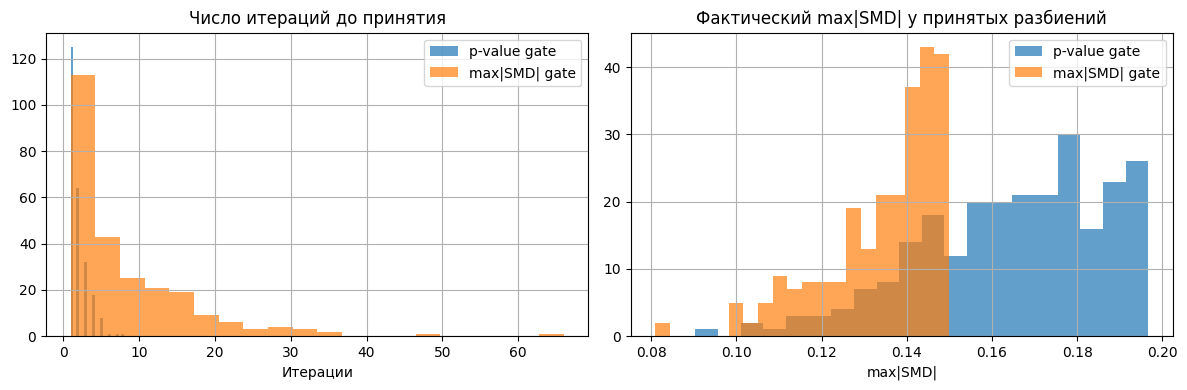

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rerand_df["iter_pvalue_gate"].dropna(), bins=20, alpha=0.7, label="p-value gate")
axes[0].hist(rerand_df["iter_smd_gate"].dropna(), bins=20, alpha=0.7, label="max|SMD| gate")
axes[0].set_title("Число итераций до принятия")
axes[0].set_xlabel("Итерации")
axes[0].legend()

axes[1].hist(rerand_df["accepted_max_abs_smd_pvalue_gate"].dropna(), bins=20, alpha=0.7, label="p-value gate")
axes[1].hist(rerand_df["accepted_max_abs_smd_smd_gate"].dropna(), bins=20, alpha=0.7, label="max|SMD| gate")
axes[1].set_title("Фактический max|SMD| у принятых разбиений")
axes[1].set_xlabel("max|SMD|")
axes[1].legend()

plt.tight_layout()
plt.show()


Интерпретация: правило на основе p-value и правило на основе `max|SMD|` отвечают на разные вопросы. Первое контролирует статистическое «удивление», второе — величину фактического дисбаланса. Для инженерного контроля качества разбиения второе обычно интерпретируется проще.

## Эксперимент 4. Общий многомерный тест: критерий Хотеллинга $T^2$

In [11]:
hotelling_rows = []
for k in [2, 5, 10]:
    pvals = []
    for r in range(600):
        X, g = simulate_null_dataset(n=300, k=k, rho=0.4, seed=60_000 + 100 * k + r)
        _, _, pv = hotellings_t2_two_sample(X, g)
        pvals.append(pv)
    hotelling_rows.append({
        "K_quantitative": k,
        "share_p_below_0_05": np.mean(np.array(pvals) < 0.05)
    })

hotelling_df = pd.DataFrame(hotelling_rows)
hotelling_df


,K_quantitative,share_p_below_0_05
0,2,0.036667
1,5,0.048333
2,10,0.050000


Критерий Хотеллинга $T^2$ полезен как единый общий тест по нескольким количественным признакам, особенно когда важно учитывать их совместную структуру. Однако он менее удобен при смешанном наборе признаков и при высокой размерности, поэтому в прикладной системе его разумно рассматривать как дополнительный агрегированный тест, а не как универсальную замену всех диагностик.

## Краткое резюме

1. При росте числа признаков вероятность хотя бы одного случайного малого p-value быстро растёт.
2. Поправки на множественность уменьшают частоту ложных отклонений, но не делают p-value мерой содержательного дисбаланса.
3. Для контроля качества разбиения правило на основе величины дисбаланса (например, max|SMD|) обычно проще интерпретировать.
4. Критерий Хотеллинга T^2 можно использовать как общий тест по нескольким количественным признакам, но его лучше рассматривать как дополнительный инструмент.